# 📊 Análise de Risco e Otimização de Carteira de Criptomoedas

**Módulos cobertos:**
- ✅ Coleta e tratamento de dados via `yfinance`
- ✅ Simulação de Monte Carlo (fronteira eficiente)
- ✅ Otimização de Markowitz (máximo Sharpe / mínima volatilidade)
- ✅ Métricas de risco: Sharpe, Alpha, Beta, VaR, CVaR, Drawdown máximo
- ✅ Rebalanceamento com Programação Linear (PuLP)
- ✅ Visualizações interativas com Plotly

---

## 1. Instalação e Importação de Dependências

In [18]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import pulp as p
from scipy import stats
from scipy.optimize import minimize
from collections import OrderedDict
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
plt.style.use('seaborn-v0_8-darkgrid')

import plotly.io as pio
pio.renderers.default = "notebook"

print('✅ Todas as bibliotecas importadas com sucesso!')

✅ Todas as bibliotecas importadas com sucesso!


## 2. Configurações da Carteira

In [8]:
# ============================================================
# CONFIGURAÇÕES — edite aqui conforme sua necessidade
# ============================================================

TICKERS = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD']
BENCHMARK = '^GSPC'          # S&P 500 como benchmark
DATA_INICIO = '2024-01-01'
DATA_FIM    = '2026-12-31'

TAXA_LIVRE_RISCO = 0.05      # 5% ao ano (referência USD)
CAPITAL_INICIAL  = 10_000    # USD
DIAS_UTEIS       = 365       # cripto opera 24/7
NUM_SIMULACOES   = 50_000    # Monte Carlo
NIVEL_CONFIANCA  = 0.95      # para VaR / CVaR

print(f'📌 Ativos: {TICKERS}')
print(f'📅 Período: {DATA_INICIO} → {DATA_FIM}')
print(f'💰 Capital inicial: USD {CAPITAL_INICIAL:,.0f}')

📌 Ativos: ['BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'ADA-USD', 'XRP-USD']
📅 Período: 2024-01-01 → 2026-12-31
💰 Capital inicial: USD 10,000


## 3. Coleta e Tratamento de Dados

In [9]:
# Baixar preços de fechamento ajustados
raw = yf.download(TICKERS + [BENCHMARK], start=DATA_INICIO, end=DATA_FIM, auto_adjust=True, progress=False)
precos = raw['Close'].dropna()

# Separar benchmark
benchmark_prices = precos[BENCHMARK]
precos_cripto    = precos[TICKERS]

print(f'📊 Shape dos dados: {precos_cripto.shape}')
print(f'📅 Período real: {precos_cripto.index[0].date()} → {precos_cripto.index[-1].date()}')
precos_cripto.tail()

📊 Shape dos dados: (552, 6)
📅 Período real: 2024-01-02 → 2026-03-16


Ticker,BTC-USD,ETH-USD,BNB-USD,SOL-USD,ADA-USD,XRP-USD
Date,,,,,,
2026-03-10,69926.921875,2037.120483,641.879211,85.838226,0.262012,1.386425
2026-03-11,70204.882812,2051.573242,651.478333,86.564934,0.262537,1.384877
2026-03-12,70493.460938,2073.136230,652.135010,86.867790,0.263198,1.384649
2026-03-13,70968.265625,2092.563477,655.881958,88.153290,0.265694,1.398908
2026-03-16,74382.031250,2361.485352,680.546936,96.356102,0.288405,1.533227


In [10]:
# Calcular retornos diários e retornos acumulados
retornos       = precos_cripto.pct_change().dropna()
ret_benchmark  = benchmark_prices.pct_change().dropna()

retorno_acumulado = (1 + retornos).cumprod()
precos_normalizados = precos_cripto / precos_cripto.iloc[0]

# Estatísticas descritivas
print('📈 Retornos diários — estatísticas descritivas:')
retornos.describe().round(4)

📈 Retornos diários — estatísticas descritivas:


Ticker,BTC-USD,ETH-USD,BNB-USD,SOL-USD,ADA-USD,XRP-USD
count,551.0000,551.0000,551.0000,551.0000,551.0000,551.0000
mean,0.0014,0.0010,0.0020,0.0011,0.0002,0.0030
std,0.0317,0.0448,0.0355,0.0504,0.0563,0.0542
min,-0.1413,-0.1905,-0.1442,-0.1593,-0.2217,-0.1966
25%,-0.0162,-0.0254,-0.0157,-0.0316,-0.0309,-0.0231
50%,-0.0000,-0.0002,0.0013,-0.0009,-0.0033,-0.0021
75%,0.0173,0.0223,0.0185,0.0333,0.0253,0.0217
max,0.1588,0.2180,0.1723,0.1462,0.3830,0.5104


In [19]:
# Visualização: preços normalizados
fig = go.Figure()
for col in precos_normalizados.columns:
    fig.add_trace(go.Scatter(x=precos_normalizados.index, y=precos_normalizados[col], mode='lines', name=col))

fig.update_layout(
    title='Preços Normalizados (base = 1)',
    xaxis_title='Data', yaxis_title='Retorno Acumulado (base 1)',
    hovermode='x unified', template='plotly_dark'
)
fig.show()

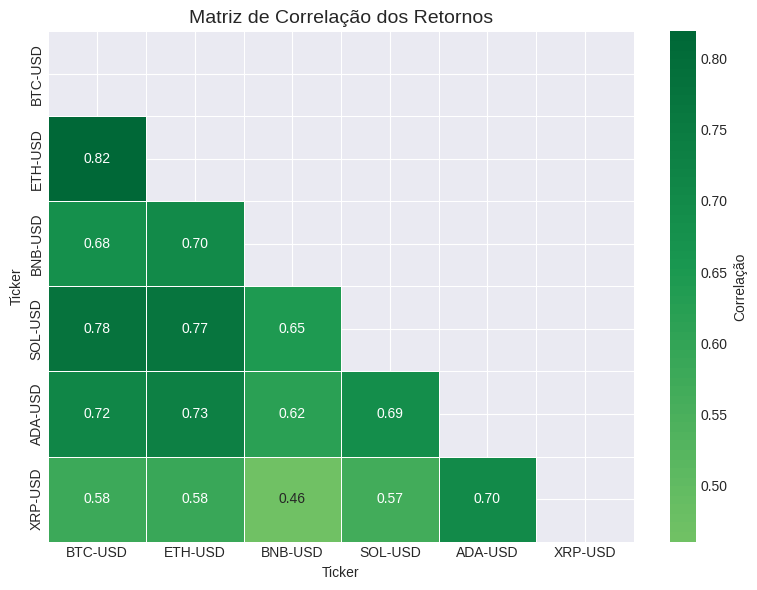

In [12]:
# Heatmap de correlação
corr = retornos.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={'label': 'Correlação'})
ax.set_title('Matriz de Correlação dos Retornos', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Simulação de Monte Carlo — Fronteira Eficiente

In [20]:
%%time
retornos_medios = retornos.mean()
cov_matrix      = retornos.cov()
n_ativos        = len(TICKERS)

np.random.seed(42)
resultados = np.zeros((n_ativos + 3, NUM_SIMULACOES))

for i in range(NUM_SIMULACOES):
    pesos  = np.random.dirichlet(np.ones(n_ativos))  # pesos somam 1, todos >= 0
    ret_p  = np.sum(retornos_medios * pesos) * DIAS_UTEIS
    vol_p  = np.sqrt(pesos @ cov_matrix.values @ pesos) * np.sqrt(DIAS_UTEIS)
    sharpe = (ret_p - TAXA_LIVRE_RISCO) / vol_p

    resultados[0, i] = ret_p
    resultados[1, i] = vol_p
    resultados[2, i] = sharpe
    resultados[3:, i] = pesos

colunas = ['retorno', 'volatilidade', 'sharpe'] + TICKERS
sim_df  = pd.DataFrame(resultados.T, columns=colunas)

max_sharpe_port = sim_df.loc[sim_df['sharpe'].idxmax()]
min_vol_port    = sim_df.loc[sim_df['volatilidade'].idxmin()]

print(f'✅ {NUM_SIMULACOES:,} simulações concluídas')
print(f'\n🏆 Carteira Máximo Sharpe:')
print(f'   Retorno: {max_sharpe_port["retorno"]:.2%} | Volatilidade: {max_sharpe_port["volatilidade"]:.2%} | Sharpe: {max_sharpe_port["sharpe"]:.3f}')
print(f'\n🛡️  Carteira Mínima Volatilidade:')
print(f'   Retorno: {min_vol_port["retorno"]:.2%} | Volatilidade: {min_vol_port["volatilidade"]:.2%} | Sharpe: {min_vol_port["sharpe"]:.3f}')

✅ 50,000 simulações concluídas

🏆 Carteira Máximo Sharpe:
   Retorno: 84.02% | Volatilidade: 69.03% | Sharpe: 1.145

🛡️  Carteira Mínima Volatilidade:
   Retorno: 60.13% | Volatilidade: 58.94% | Sharpe: 0.935
CPU times: user 3.37 s, sys: 175 ms, total: 3.54 s
Wall time: 3.31 s


In [21]:
# Gráfico da Fronteira Eficiente
fig = go.Figure()

# Nuvem de portfólios
fig.add_trace(go.Scatter(
    x=sim_df['volatilidade'], y=sim_df['retorno'],
    mode='markers',
    marker=dict(color=sim_df['sharpe'], colorscale='RdYlGn',
                size=3, opacity=0.5, showscale=True,
                colorbar=dict(title='Índice Sharpe')),
    name='Simulações', hovertemplate='Vol: %{x:.2%}<br>Ret: %{y:.2%}<extra></extra>'
))

# Máximo Sharpe
fig.add_trace(go.Scatter(
    x=[max_sharpe_port['volatilidade']], y=[max_sharpe_port['retorno']],
    mode='markers+text', marker=dict(color='red', size=16, symbol='star'),
    text=['Máx. Sharpe'], textposition='top right', name='Máximo Sharpe'
))

# Mínima volatilidade
fig.add_trace(go.Scatter(
    x=[min_vol_port['volatilidade']], y=[min_vol_port['retorno']],
    mode='markers+text', marker=dict(color='lime', size=16, symbol='star'),
    text=['Mín. Vol'], textposition='top right', name='Mínima Volatilidade'
))

fig.update_layout(
    title='Fronteira Eficiente — Monte Carlo',
    xaxis_title='Volatilidade Anual', yaxis_title='Retorno Anual',
    xaxis_tickformat='.0%', yaxis_tickformat='.0%',
    template='plotly_dark', hovermode='closest'
)
fig.show()

## 5. Otimização de Markowitz (SciPy)

In [22]:
# Funções auxiliares
def portfolio_performance(pesos, retornos_medios, cov_matrix, dias=365, rf=0.05):
    ret = np.sum(retornos_medios * pesos) * dias
    vol = np.sqrt(pesos @ cov_matrix.values @ pesos) * np.sqrt(dias)
    sharpe = (ret - rf) / vol
    return ret, vol, sharpe

def neg_sharpe(pesos, retornos_medios, cov_matrix, dias=365, rf=0.05):
    _, _, sharpe = portfolio_performance(pesos, retornos_medios, cov_matrix, dias, rf)
    return -sharpe

def min_volatilidade(pesos, retornos_medios, cov_matrix, dias=365, rf=0.05):
    _, vol, _ = portfolio_performance(pesos, retornos_medios, cov_matrix, dias, rf)
    return vol

# Restrições e limites
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds      = tuple((0, 1) for _ in TICKERS)
pesos_ini   = np.array([1 / n_ativos] * n_ativos)

# Otimização: máximo Sharpe
opt_sharpe = minimize(
    neg_sharpe, pesos_ini,
    args=(retornos_medios, cov_matrix, DIAS_UTEIS, TAXA_LIVRE_RISCO),
    method='SLSQP', bounds=bounds, constraints=constraints
)

# Otimização: mínima volatilidade
opt_vol = minimize(
    min_volatilidade, pesos_ini,
    args=(retornos_medios, cov_matrix, DIAS_UTEIS, TAXA_LIVRE_RISCO),
    method='SLSQP', bounds=bounds, constraints=constraints
)

pesos_max_sharpe = opt_sharpe.x
pesos_min_vol    = opt_vol.x

ret_ms, vol_ms, sr_ms = portfolio_performance(pesos_max_sharpe, retornos_medios, cov_matrix, DIAS_UTEIS, TAXA_LIVRE_RISCO)
ret_mv, vol_mv, sr_mv = portfolio_performance(pesos_min_vol,    retornos_medios, cov_matrix, DIAS_UTEIS, TAXA_LIVRE_RISCO)

print('=' * 55)
print(f'  🏆 Carteira Máximo Sharpe (Markowitz)')
print('=' * 55)
for t, w in zip(TICKERS, pesos_max_sharpe):
    print(f'  {t:<12} {w:>8.2%}')
print(f'  {"─"*30}')
print(f'  Retorno Anual  : {ret_ms:>8.2%}')
print(f'  Volatilidade   : {vol_ms:>8.2%}')
print(f'  Índice Sharpe  : {sr_ms:>8.3f}')
print()
print('=' * 55)
print(f'  🛡️  Carteira Mínima Volatilidade (Markowitz)')
print('=' * 55)
for t, w in zip(TICKERS, pesos_min_vol):
    print(f'  {t:<12} {w:>8.2%}')
print(f'  {"─"*30}')
print(f'  Retorno Anual  : {ret_mv:>8.2%}')
print(f'  Volatilidade   : {vol_mv:>8.2%}')
print(f'  Índice Sharpe  : {sr_mv:>8.3f}')

  🏆 Carteira Máximo Sharpe (Markowitz)
  BTC-USD         0.00%
  ETH-USD         0.00%
  BNB-USD        61.31%
  SOL-USD         0.00%
  ADA-USD         0.00%
  XRP-USD        38.69%
  ──────────────────────────────
  Retorno Anual  :   88.20%
  Volatilidade   :   69.80%
  Índice Sharpe  :    1.192

  🛡️  Carteira Mínima Volatilidade (Markowitz)
  BTC-USD        67.25%
  ETH-USD         0.00%
  BNB-USD        32.75%
  SOL-USD         0.00%
  ADA-USD         0.00%
  XRP-USD         0.00%
  ──────────────────────────────
  Retorno Anual  :   59.11%
  Volatilidade   :   58.19%
  Índice Sharpe  :    0.930


In [23]:
# Traçar a fronteira eficiente real (via minimização para múltiplos alvos de retorno)
alvo_retornos = np.linspace(ret_mv, sim_df['retorno'].max() * 0.9, 80)
vols_fronteira, rets_fronteira = [], []

for alvo in alvo_retornos:
    cons = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x, r=alvo: np.sum(retornos_medios * x) * DIAS_UTEIS - r}
    ]
    res = minimize(min_volatilidade, pesos_ini,
                   args=(retornos_medios, cov_matrix, DIAS_UTEIS, TAXA_LIVRE_RISCO),
                   method='SLSQP', bounds=bounds, constraints=cons)
    if res.success:
        vols_fronteira.append(res.fun)
        rets_fronteira.append(alvo)

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=sim_df['volatilidade'], y=sim_df['retorno'],
    mode='markers', marker=dict(color=sim_df['sharpe'], colorscale='Blues',
    size=2, opacity=0.3), name='Monte Carlo', showlegend=True))

fig.add_trace(go.Scatter(x=vols_fronteira, y=rets_fronteira,
    mode='lines', line=dict(color='yellow', width=3), name='Fronteira Eficiente'))

fig.add_trace(go.Scatter(x=[vol_ms], y=[ret_ms], mode='markers+text',
    marker=dict(color='red', size=14, symbol='star'),
    text=['Máx. Sharpe'], textposition='top right', name='Máx. Sharpe'))

fig.add_trace(go.Scatter(x=[vol_mv], y=[ret_mv], mode='markers+text',
    marker=dict(color='lime', size=14, symbol='star'),
    text=['Mín. Vol'], textposition='top right', name='Mín. Volatilidade'))

fig.update_layout(title='Fronteira Eficiente de Markowitz',
    xaxis_title='Volatilidade Anual', yaxis_title='Retorno Anual',
    xaxis_tickformat='.0%', yaxis_tickformat='.0%',
    template='plotly_dark')
fig.show()

In [24]:
# Comparar alocações das duas carteiras
fig = make_subplots(rows=1, cols=2, specs=[[{'type':'pie'}, {'type':'pie'}]],
                    subplot_titles=['Máximo Sharpe', 'Mínima Volatilidade'])

fig.add_trace(go.Pie(labels=TICKERS, values=pesos_max_sharpe,
    hole=0.4, textinfo='label+percent'), row=1, col=1)

fig.add_trace(go.Pie(labels=TICKERS, values=pesos_min_vol,
    hole=0.4, textinfo='label+percent'), row=1, col=2)

fig.update_layout(title='Composição das Carteiras Otimizadas', template='plotly_dark')
fig.show()

## 6. Métricas de Risco: Sharpe, Alpha, Beta, VaR, CVaR, Drawdown

In [25]:
# Retorno diário da carteira otimizada (máximo Sharpe)
retorno_carteira_diario = retornos @ pesos_max_sharpe

# Alinhar com benchmark
ret_bm = ret_benchmark.reindex(retorno_carteira_diario.index).dropna()
ret_cart = retorno_carteira_diario.reindex(ret_bm.index)

# ── Alpha e Beta (CAPM) ────────────────────────────────────
slope, intercept, r_value, p_value, std_err = stats.linregress(ret_bm.values, ret_cart.values)
beta  = slope
alpha = intercept * DIAS_UTEIS  # anualizando o alpha diário

# ── Sharpe Ratio ──────────────────────────────────────────
excesso = ret_cart - TAXA_LIVRE_RISCO / DIAS_UTEIS
sharpe  = excesso.mean() / excesso.std() * np.sqrt(DIAS_UTEIS)

# ── Sortino Ratio ─────────────────────────────────────────
downside_std = excesso[excesso < 0].std() * np.sqrt(DIAS_UTEIS)
sortino = excesso.mean() * DIAS_UTEIS / downside_std if downside_std > 0 else np.nan

# ── VaR e CVaR (paramétrico e histórico) ──────────────────
mu_d  = ret_cart.mean()
std_d = ret_cart.std()
z     = stats.norm.ppf(1 - NIVEL_CONFIANCA)

var_param = -(mu_d + z * std_d) * CAPITAL_INICIAL
var_hist  = -np.percentile(ret_cart, (1 - NIVEL_CONFIANCA) * 100) * CAPITAL_INICIAL
cvar_hist = -ret_cart[ret_cart <= np.percentile(ret_cart, (1-NIVEL_CONFIANCA)*100)].mean() * CAPITAL_INICIAL

# ── Drawdown Máximo ────────────────────────────────────────
curva_capital = (1 + ret_cart).cumprod()
pico_rolante  = curva_capital.cummax()
drawdown      = (curva_capital - pico_rolante) / pico_rolante
max_drawdown  = drawdown.min()

# ── Resumo ────────────────────────────────────────────────
print('═' * 50)
print('  📊 MÉTRICAS DA CARTEIRA — Máximo Sharpe')
print('═' * 50)
print(f'  Retorno Anualizado  : {ret_cart.mean() * DIAS_UTEIS:>10.2%}')
print(f'  Volatilidade Anual  : {ret_cart.std()  * np.sqrt(DIAS_UTEIS):>10.2%}')
print(f'  Índice de Sharpe    : {sharpe:>10.3f}')
print(f'  Índice de Sortino   : {sortino:>10.3f}')
print(f'  Alpha (CAPM, a.a.)  : {alpha:>10.2%}')
print(f'  Beta                : {beta:>10.3f}')
print(f'  R²                  : {r_value**2:>10.3f}')
print(f'  Drawdown Máximo     : {max_drawdown:>10.2%}')
print('─' * 50)
print(f'  VaR {NIVEL_CONFIANCA:.0%} Param. (1 dia) : USD {var_param:>8,.2f}')
print(f'  VaR {NIVEL_CONFIANCA:.0%} Histórico      : USD {var_hist:>8,.2f}')
print(f'  CVaR {NIVEL_CONFIANCA:.0%} Histórico     : USD {cvar_hist:>8,.2f}')
print('═' * 50)

══════════════════════════════════════════════════
  📊 MÉTRICAS DA CARTEIRA — Máximo Sharpe
══════════════════════════════════════════════════
  Retorno Anualizado  :     88.20%
  Volatilidade Anual  :     69.80%
  Índice de Sharpe    :      1.192
  Índice de Sortino   :      1.805
  Alpha (CAPM, a.a.)  :     57.63%
  Beta                :      1.240
  R²                  :      0.112
  Drawdown Máximo     :    -54.83%
──────────────────────────────────────────────────
  VaR 95% Param. (1 dia) : USD   576.79
  VaR 95% Histórico      : USD   502.74
  CVaR 95% Histórico     : USD   801.47
══════════════════════════════════════════════════


In [26]:
# Visualização: curva de capital e drawdown
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Curva de Capital (USD)', 'Drawdown (%)'],
                    row_heights=[0.65, 0.35])

fig.add_trace(go.Scatter(x=curva_capital.index,
    y=curva_capital * CAPITAL_INICIAL,
    mode='lines', line=dict(color='#00d4ff'), name='Carteira'),
    row=1, col=1)

bm_norm = (1 + ret_bm).cumprod() * CAPITAL_INICIAL
fig.add_trace(go.Scatter(x=bm_norm.index, y=bm_norm,
    mode='lines', line=dict(color='orange', dash='dash'), name='S&P 500'),
    row=1, col=1)

fig.add_trace(go.Scatter(x=drawdown.index, y=drawdown * 100,
    fill='tozeroy', mode='lines',
    line=dict(color='red', width=0.8),
    fillcolor='rgba(255,0,0,0.25)', name='Drawdown'),
    row=2, col=1)

fig.update_yaxes(tickprefix='$', row=1, col=1)
fig.update_yaxes(ticksuffix='%', row=2, col=1)
fig.update_layout(title='Performance da Carteira vs S&P 500',
                  template='plotly_dark', hovermode='x unified')
fig.show()

In [27]:
# Distribuição de retornos diários com VaR marcado
threshold_hist  = np.percentile(ret_cart, (1 - NIVEL_CONFIANCA) * 100)

fig = go.Figure()
fig.add_trace(go.Histogram(x=ret_cart, nbinsx=120, name='Retornos Diários',
    marker_color='steelblue', opacity=0.7,
    histnorm='probability density'))

# Curva normal ajustada
x_range = np.linspace(ret_cart.min(), ret_cart.max(), 300)
y_norm  = stats.norm.pdf(x_range, mu_d, std_d)
fig.add_trace(go.Scatter(x=x_range, y=y_norm, mode='lines',
    line=dict(color='white', width=2), name='Normal ajustada'))

fig.add_vline(x=threshold_hist, line_color='red', line_dash='dash',
    annotation_text=f'VaR {NIVEL_CONFIANCA:.0%}', annotation_position='top left')

fig.update_layout(title='Distribuição dos Retornos Diários',
    xaxis_title='Retorno Diário', yaxis_title='Densidade',
    xaxis_tickformat='.1%', template='plotly_dark')
fig.show()

In [28]:
# Regressão CAPM: carteira vs benchmark
x_line = np.linspace(ret_bm.min(), ret_bm.max(), 100)
y_line = intercept + slope * x_line

fig = go.Figure()
fig.add_trace(go.Scatter(x=ret_bm, y=ret_cart, mode='markers',
    marker=dict(color='steelblue', size=4, opacity=0.5), name='Retornos'))
fig.add_trace(go.Scatter(x=x_line, y=y_line, mode='lines',
    line=dict(color='red', width=2), name=f'CAPM (β={beta:.3f})'))

fig.update_layout(
    title=f'Regressão CAPM — α={alpha:.2%} a.a. | β={beta:.3f} | R²={r_value**2:.3f}',
    xaxis_title='Retorno S&P 500', yaxis_title='Retorno Carteira',
    xaxis_tickformat='.1%', yaxis_tickformat='.1%',
    template='plotly_dark'
)
fig.show()

## 7. Rebalanceamento com Programação Linear (PuLP)

In [29]:
# ============================================================
# Rebalanceamento com restrições personalizadas via PuLP
# ============================================================
# Objetivo: maximizar retorno esperado anual
# Restrições:
#   (a) Nenhum ativo acima de 40%
#   (b) BTC + ETH juntos >= 30% (ativos de maior liquidez)
#   (c) Volatilidade do portfólio <= 0.75 (teto de risco)
#   (d) Pesos somam 1 e são não-negativos
# ============================================================

prob = p.LpProblem('Rebalanceamento_Cripto', p.LpMaximize)

# Variáveis de decisão
pesos_vars = {t: p.LpVariable(f'w_{t.replace("-","_")}', lowBound=0, upBound=0.40) for t in TICKERS}

# Retornos esperados (médias históricas anualizadas)
ret_esperados = {t: retornos_medios[t] * DIAS_UTEIS for t in TICKERS}

# Função objetivo: maximizar retorno
prob += p.lpSum(ret_esperados[t] * pesos_vars[t] for t in TICKERS)

# Restrições
prob += p.lpSum(pesos_vars[t] for t in TICKERS) == 1   # soma = 100%

# BTC + ETH >= 30%
btc_eth = [t for t in TICKERS if t in ['BTC-USD', 'ETH-USD']]
if btc_eth:
    prob += p.lpSum(pesos_vars[t] for t in btc_eth) >= 0.30

# Custo de transação fictício: incentivar mínimo de alocação por ativo (>= 5% se incluído)
# (simplificado: sem variáveis binárias, apenas limite inferior suave)

# Resolver
status = prob.solve(p.PULP_CBC_CMD(msg=0))

pesos_pulp = {t: p.value(pesos_vars[t]) for t in TICKERS}
ret_pulp   = sum(ret_esperados[t] * pesos_pulp[t] for t in TICKERS)

w_arr = np.array([pesos_pulp[t] for t in TICKERS])
vol_pulp = np.sqrt(w_arr @ cov_matrix.values @ w_arr) * np.sqrt(DIAS_UTEIS)

print(f'Status: {p.LpStatus[status]}')
print()
print('═' * 45)
print('  ⚖️  Rebalanceamento Otimizado (PuLP)')
print('═' * 45)
for t in TICKERS:
    print(f'  {t:<12} {pesos_pulp[t]:>8.2%}')
print(f'  {"─"*30}')
print(f'  Retorno esperado : {ret_pulp:>8.2%}')
print(f'  Volatilidade est.: {vol_pulp:>8.2%}')
print(f'  Capital inicial  : USD {CAPITAL_INICIAL:>8,.0f}')
print('─' * 45)
print('  Alocação em USD:')
for t in TICKERS:
    print(f'  {t:<12} USD {pesos_pulp[t] * CAPITAL_INICIAL:>8,.2f}')

Status: Optimal

═════════════════════════════════════════════
  ⚖️  Rebalanceamento Otimizado (PuLP)
═════════════════════════════════════════════
  BTC-USD        30.00%
  ETH-USD         0.00%
  BNB-USD        30.00%
  SOL-USD         0.00%
  ADA-USD         0.00%
  XRP-USD        40.00%
  ──────────────────────────────
  Retorno esperado :   81.77%
  Volatilidade est.:   67.93%
  Capital inicial  : USD   10,000
─────────────────────────────────────────────
  Alocação em USD:
  BTC-USD      USD 3,000.00
  ETH-USD      USD     0.00
  BNB-USD      USD 3,000.00
  SOL-USD      USD     0.00
  ADA-USD      USD     0.00
  XRP-USD      USD 4,000.00


In [30]:
# Comparar as três estratégias de alocação
df_comp = pd.DataFrame({
    'Ativo': TICKERS,
    'Igualitária': [1/n_ativos] * n_ativos,
    'Máx. Sharpe': pesos_max_sharpe,
    'PuLP Rebalanceado': [pesos_pulp[t] for t in TICKERS]
})

fig = go.Figure()
for col in ['Igualitária', 'Máx. Sharpe', 'PuLP Rebalanceado']:
    fig.add_trace(go.Bar(name=col, x=df_comp['Ativo'], y=df_comp[col],
                         text=[f'{v:.1%}' for v in df_comp[col]],
                         textposition='outside'))

fig.update_layout(barmode='group', title='Comparação de Estratégias de Alocação',
    yaxis_title='Peso', yaxis_tickformat='.0%',
    template='plotly_dark')
fig.show()

## 8. Resumo Final e Comparação de Estratégias

In [31]:
# Calcular curvas de capital para cada estratégia
estrategias = {
    'Igualitária':        np.array([1/n_ativos] * n_ativos),
    'Mín. Volatilidade':  pesos_min_vol,
    'Máx. Sharpe':        pesos_max_sharpe,
    'PuLP Rebalanceado':  np.array([pesos_pulp[t] for t in TICKERS])
}

fig = go.Figure()
colors = ['#aaaaaa', '#4ecdc4', '#ff6b6b', '#ffd93d']

resumo = []
for (nome, pesos_e), cor in zip(estrategias.items(), colors):
    ret_e   = retornos @ pesos_e
    curva_e = (1 + ret_e).cumprod() * CAPITAL_INICIAL

    ret_an  = ret_e.mean() * DIAS_UTEIS
    vol_an  = ret_e.std()  * np.sqrt(DIAS_UTEIS)
    sr_e    = (ret_an - TAXA_LIVRE_RISCO) / vol_an
    dd_e    = ((1 + ret_e).cumprod() / (1 + ret_e).cumprod().cummax() - 1).min()

    resumo.append({'Estratégia': nome, 'Retorno a.a.': f'{ret_an:.2%}',
                   'Volatilidade': f'{vol_an:.2%}', 'Sharpe': f'{sr_e:.3f}',
                   'Max Drawdown': f'{dd_e:.2%}',
                   'Capital Final': f'USD {curva_e.iloc[-1]:,.0f}'})

    fig.add_trace(go.Scatter(x=curva_e.index, y=curva_e,
        mode='lines', line=dict(color=cor, width=2), name=nome))

fig.update_layout(title='Evolução do Capital — Comparação de Estratégias',
    xaxis_title='Data', yaxis_title='Capital (USD)',
    yaxis_tickprefix='$', template='plotly_dark', hovermode='x unified')
fig.show()

pd.DataFrame(resumo).set_index('Estratégia')

,Retorno a.a.,Volatilidade,Sharpe,Max Drawdown,Capital Final
Estratégia,,,,,
Igualitária,53.18%,73.87%,0.652,-60.06%,"USD 14,784"
Mín. Volatilidade,59.11%,58.19%,0.930,-50.38%,"USD 18,912"
Máx. Sharpe,88.20%,69.80%,1.192,-54.83%,"USD 26,239"
PuLP Rebalanceado,81.77%,67.93%,1.130,-53.55%,"USD 24,307"


---
## 9. Conclusões

Este notebook cobriu o pipeline completo de análise de risco de uma carteira de criptomoedas:

| Módulo | O que foi feito |
|---|---|
| **Dados** | Download via `yfinance`, retornos diários, matriz de covariância |
| **Monte Carlo** | 50.000 carteiras simuladas com Índice de Sharpe como cor |
| **Markowitz** | Otimização via `scipy.optimize` — máx. Sharpe e mín. volatilidade |
| **Métricas** | Sharpe, Sortino, Alpha, Beta, VaR, CVaR, Drawdown máximo |
| **PuLP** | Rebalanceamento com restrições de negócio (teto por ativo, liquidez) |
| **Comparação** | Curvas de capital e tabela para 4 estratégias distintas |

**Próximos passos sugeridos:**
- Adicionar rebalanceamento periódico (mensal/trimestral)
- Incluir custos de transação reais
- Testar com janela deslizante (walk-forward)
- Adicionar modelo GARCH para volatilidade condicional